# Part 5 — Application: SAE Report Generation

**Model:** MedGemma 4B (anti-hallucination fine-tuned)  
**Task:** Generate MedWatch 3500A pharmacovigilance narratives from CRF data  
**Focus:** Structured and narrative sections with factual grounding

---

This notebook is part of the **MedGemma Clinical Trial Engine** pipeline:

```
NB1  Anti-Hallucination ──── RLFR fine-tuning for reliable medical text (MedGemma)
NB2  SAE Detection ────────── MedGemma 1.5 + MedSigLIP + HeAR (image + audio → AE)
NB3  Clinical Trial Sim ──── Rule set generation + hazard-based daily simulation
NB4  Voice Call App ────────── MedGemma 4B virtual nurse (multi-turn dialogue)
NB5  SAE Report Gen ────────── CRF data → MedWatch 3500A pharmacovigilance reports
```

---
## 1. Environment Setup

In [1]:
# ── Environment Requirements ──
# Python >= 3.10 (required: transformers >= 4.49 for Gemma3 architecture)
#   - Python 3.8 WILL NOT WORK (transformers caps at 4.46.3)
# GPU: NVIDIA GPU with >= 16 GB VRAM recommended

# ── Install dependencies ──
!pip install -q torch transformers accelerate matplotlib pandas huggingface-hub sentencepiece

# ── HuggingFace login ──
# Required for newmes models. Get your token at: https://huggingface.co/settings/tokens
import os
from huggingface_hub import login

HF_TOKEN = ""  # <-- paste your HuggingFace token here

if HF_TOKEN:
    login(token=HF_TOKEN)
elif os.environ.get("HF_TOKEN"):
    login(token=os.environ["HF_TOKEN"])
else:
    login()


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
import json
import re
import time
import textwrap
from datetime import date, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import pandas as pd
import torch
from IPython.display import display, HTML, Markdown

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    gpu_mem = getattr(torch.cuda.get_device_properties(0), 'total_memory',
                      getattr(torch.cuda.get_device_properties(0), 'total_mem', 0))
    print(f"GPU Memory: {gpu_mem / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX A5000
GPU Memory: 25.4 GB


---
## 2. Download & Load Model from HuggingFace

In [3]:
# ============================================================
# Configuration
# ============================================================

MODEL_ID = "newmes/medgemma-4b-antihallu"
GPU_ID = 0   # ← change to your GPU index

DEVICE = f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu"
MAX_NEW_TOKENS_NARRATIVE = 1024
MAX_NEW_TOKENS_STRUCTURED = 512
TEMPERATURE_NARRATIVE = 0.3
TEMPERATURE_STRUCTURED = 0.1

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM

print(f"Loading model: {MODEL_ID}")
print(f"Device: {DEVICE}")

t0 = time.time()

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    dtype=torch.bfloat16,
    device_map={"": GPU_ID},
    trust_remote_code=True,
)
model.eval()

load_time = time.time() - t0
param_count = sum(p.numel() for p in model.parameters()) / 1e9

print(f"\nModel loaded in {load_time:.1f}s")
print(f"Parameters: {param_count:.2f}B")
print(f"Dtype: {next(model.parameters()).dtype}")
if torch.cuda.is_available():
    mem_gb = torch.cuda.memory_allocated() / 1e9
    print(f"GPU Memory used: {mem_gb:.2f} GB")

Loading model: newmes/medgemma-4b-antihallu
Device: cuda:0


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/130 [00:00<?, ?B/s]


Model loaded in 136.5s
Parameters: 4.30B
Dtype: torch.bfloat16
GPU Memory used: 8.60 GB


---
## 3. Sample Patient Data (CRF Format)

We use CDASH-compliant CRF domains:
- **DM** (Demographics) - Subject ID, age, sex
- **AE** (Adverse Event) - Term, onset, severity, CTCAE grade, outcome
- **EC** (Exposure) - Drug dose, frequency, route, start/end dates
- **LB** (Laboratory) - Lab results with reference ranges
- **CM** (Concomitant Meds) - Baseline and AE treatment medications
- **MH** (Medical History) - Prior conditions
- **VS** (Vital Signs) - Weight, height, vitals

In [5]:
# Sample patient: Febrile neutropenia (Grade 3, hospitalized, rechallenge)
SAMPLE_PATIENT = {
    "dm": {
        "SUBJID": "PT-AE-001",
        "AGE": 52,
        "SEX": "Male",
        "RACE": "Black or African American",
        "ETHNIC": "Not Hispanic or Latino"
    },
    "ae": {
        "AETERM": "Febrile neutropenia",
        "AESTDAT": "2025-10-18",
        "AEENDAT": "2025-11-02",
        "AESEV": "SEVERE",
        "AESER": "Y",
        "AETOXGR": "3",
        "AEREL": "Related",
        "AEACN": "DRUG INTERRUPTED",
        "AEOUT": "RECOVERED/RESOLVED",
        "AESDTH": "N", "AESLIFE": "N", "AESHOSP": "Y",
        "AESDISAB": "N", "AESCONG": "N", "AESMIE": "Y",
        "AEHOSPSTDAT": "2025-10-18",
        "AEHOSPENDAT": "2025-11-02"
    },
    "ec": [
        {
            "ECDSTXT": "5.4 mg/kg", "ECDOSFRQ": "Q3W",
            "ECROUTE": "Intravenous",
            "ECSTDAT": "2025-09-22", "ECENDAT": "2025-10-18",
            "ECDOSADJ": "Drug interrupted due to febrile neutropenia"
        },
        {
            "ECDSTXT": "5.4 mg/kg", "ECDOSFRQ": "Q3W",
            "ECROUTE": "Intravenous",
            "ECSTDAT": "2025-11-10", "ECENDAT": None,
            "ECDOSADJ": "Resumed at same dose after neutropenia resolution"
        }
    ],
    "lb": {
        "records": [
            {"LBTESTCD": "ANC", "LBTEST": "Absolute Neutrophil Count",
             "LBORRES": "0.3", "LBORRESU": "10^3/uL",
             "LBORNRLO": "1.5", "LBORNRHI": "8.0", "LBDAT": "2025-10-18"},
            {"LBTESTCD": "WBC", "LBTEST": "White Blood Cell Count",
             "LBORRES": "0.8", "LBORRESU": "10^3/uL",
             "LBORNRLO": "4.0", "LBORNRHI": "11.0", "LBDAT": "2025-10-18"},
            {"LBTESTCD": "PLT", "LBTEST": "Platelet Count",
             "LBORRES": "125", "LBORRESU": "10^3/uL",
             "LBORNRLO": "150", "LBORNRHI": "400", "LBDAT": "2025-10-18"},
            {"LBTESTCD": "HGB", "LBTEST": "Hemoglobin",
             "LBORRES": "10.2", "LBORRESU": "g/dL",
             "LBORNRLO": "13.5", "LBORNRHI": "17.5", "LBDAT": "2025-10-18"}
        ]
    },
    "cm": {
        "records": [
            {"CMTRT": "Filgrastim", "CMINDC": "Febrile neutropenia",
             "CMDSTXT": "5 mcg/kg SC daily",
             "CMSTDAT": "2025-10-19", "CMENDAT": "2025-10-28", "CMCAT": "AE_TREATMENT"},
            {"CMTRT": "Piperacillin-tazobactam", "CMINDC": "Febrile neutropenia empiric therapy",
             "CMDSTXT": "4.5 g IV Q6H",
             "CMSTDAT": "2025-10-18", "CMENDAT": "2025-10-25", "CMCAT": "AE_TREATMENT"}
        ]
    },
    "mh": {
        "records": [
            {"MHTERM": "HER2-positive metastatic breast cancer",
             "MHSTDAT": "2025-05-01", "MHENDAT": None, "MHONGO": "Y"},
            {"MHTERM": "Prior chemotherapy with docetaxel",
             "MHSTDAT": "2025-06-01", "MHENDAT": "2025-08-15", "MHONGO": "N"}
        ]
    },
    "vs": {
        "records": [
            {"VSTESTCD": "TEMP", "VSORRES": "38.9", "VSORRESU": "C", "VSDAT": "2025-10-18"},
            {"VSTESTCD": "SYSBP", "VSORRES": "118", "VSORRESU": "mmHg", "VSDAT": "2025-10-18"},
            {"VSTESTCD": "DIABP", "VSORRES": "72", "VSORRESU": "mmHg", "VSDAT": "2025-10-18"}
        ],
        "WEIGHT": 88.0, "HEIGHT": 180.0
    },
    "imaging": {
        "records": [
            {"IMG_MODALITY": "CXR", "IMG_REGION": "Chest", "IMG_DAT": "2025-10-18",
             "IMG_FINDINGS": "Clear lung fields bilaterally. No infiltrates or pleural effusion.",
             "IMG_IMPRESSION": "No acute cardiopulmonary abnormality.",
             "IMG_PLEFF": "N", "IMG_CONSOL": "N"}
        ]
    },
    "microbiology": {
        "records": [
            {"MB_SPECIMEN": "Blood", "MB_TEST": "Culture", "MB_DAT": "2025-10-15",
             "MB_RESULT": "No growth (48hr)", "MB_ORGANISM": None, "MB_SENSITIVITY": None}
        ]
    },
    "consultation": {
        "records": [
            {"CONSULT_SPECIALTY": "Infectious Disease", "CONSULT_DAT": "2025-10-16",
             "CONSULT_IMPRESSION": "Febrile neutropenia in setting of ADC therapy. Cultures negative. Recommend empiric broad-spectrum antibiotics and G-CSF support."}
        ]
    }
}

print(f"Patient: {SAMPLE_PATIENT['dm']['SUBJID']}")
print(f"  Age/Sex: {SAMPLE_PATIENT['dm']['AGE']}y {SAMPLE_PATIENT['dm']['SEX']}")
print(f"  AE: {SAMPLE_PATIENT['ae']['AETERM']} (Grade {SAMPLE_PATIENT['ae']['AETOXGR']})")
print(f"  Serious: {SAMPLE_PATIENT['ae']['AESER']} | Outcome: {SAMPLE_PATIENT['ae']['AEOUT']}")
print(f"  Exposure periods: {len(SAMPLE_PATIENT['ec'])}")
print(f"  Lab records: {len(SAMPLE_PATIENT['lb']['records'])}")

Patient: PT-AE-001
  Age/Sex: 52y Male
  AE: Febrile neutropenia (Grade 3)
  Serious: Y | Outcome: RECOVERED/RESOLVED
  Exposure periods: 2
  Lab records: 4


### 3.1 Patient Timeline Visualization

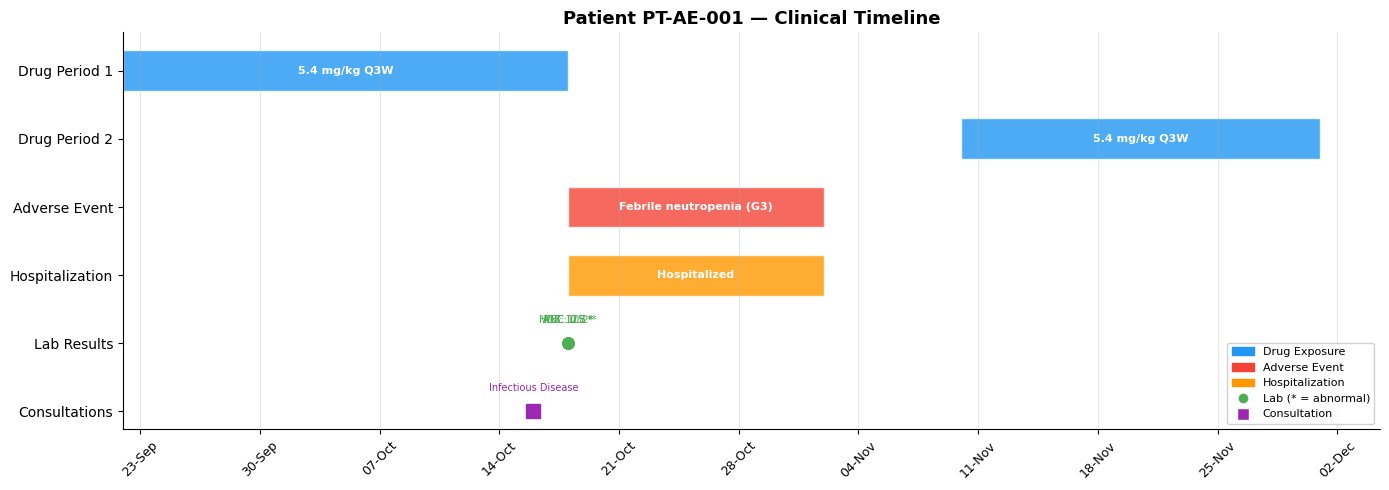

In [6]:
def plot_patient_timeline(patient):
    """Visualize the clinical timeline: drug exposure, AE, labs, hospitalizations."""
    fig, ax = plt.subplots(figsize=(14, 5))
    
    colors = {
        "drug": "#2196F3",
        "ae": "#F44336",
        "hosp": "#FF9800",
        "lab": "#4CAF50",
        "consult": "#9C27B0",
        "imaging": "#00BCD4",
    }
    
    y_pos = 0
    yticks, ylabels = [], []
    
    # Drug exposure periods
    for i, ec in enumerate(patient["ec"]):
        start = datetime.strptime(ec["ECSTDAT"], "%Y-%m-%d")
        end = datetime.strptime(ec["ECENDAT"], "%Y-%m-%d") if ec["ECENDAT"] else datetime(2025, 12, 1)
        ax.barh(y_pos, (end - start).days, left=start, height=0.6,
                color=colors["drug"], alpha=0.8, edgecolor="white")
        label = f"{ec['ECDSTXT']} {ec['ECDOSFRQ']}"
        ax.text(start + (end - start) / 2, y_pos, label,
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        yticks.append(y_pos)
        ylabels.append(f"Drug Period {i+1}")
        y_pos -= 1
    
    # AE period
    ae = patient["ae"]
    ae_start = datetime.strptime(ae["AESTDAT"], "%Y-%m-%d")
    ae_end = datetime.strptime(ae["AEENDAT"], "%Y-%m-%d") if ae.get("AEENDAT") else datetime(2025, 12, 1)
    ax.barh(y_pos, (ae_end - ae_start).days, left=ae_start, height=0.6,
            color=colors["ae"], alpha=0.8, edgecolor="white")
    ax.text(ae_start + (ae_end - ae_start) / 2, y_pos,
            f"{ae['AETERM']} (G{ae['AETOXGR']})",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    yticks.append(y_pos)
    ylabels.append("Adverse Event")
    y_pos -= 1
    
    # Hospitalization
    if ae.get("AESHOSP") == "Y" and ae.get("AEHOSPSTDAT"):
        h_start = datetime.strptime(ae["AEHOSPSTDAT"], "%Y-%m-%d")
        h_end = datetime.strptime(ae["AEHOSPENDAT"], "%Y-%m-%d") if ae.get("AEHOSPENDAT") else ae_end
        ax.barh(y_pos, (h_end - h_start).days, left=h_start, height=0.6,
                color=colors["hosp"], alpha=0.8, edgecolor="white")
        ax.text(h_start + (h_end - h_start) / 2, y_pos, "Hospitalized",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        yticks.append(y_pos)
        ylabels.append("Hospitalization")
        y_pos -= 1
    
    # Lab events
    for r in patient["lb"]["records"]:
        lab_date = datetime.strptime(r["LBDAT"], "%Y-%m-%d")
        ax.plot(lab_date, y_pos, "o", color=colors["lab"], markersize=8, zorder=5)
        val = float(r["LBORRES"])
        lo = float(r["LBORNRLO"]) if r.get("LBORNRLO") else None
        flag = " *" if (lo and val < lo) else ""
        ax.text(lab_date, y_pos + 0.3, f"{r['LBTESTCD']}: {r['LBORRES']}{flag}",
                fontsize=7, ha="center", color=colors["lab"])
    yticks.append(y_pos)
    ylabels.append("Lab Results")
    y_pos -= 1
    
    # Consultations
    for r in patient.get("consultation", {}).get("records", []):
        c_date = datetime.strptime(r["CONSULT_DAT"], "%Y-%m-%d")
        ax.plot(c_date, y_pos, "s", color=colors["consult"], markersize=10, zorder=5)
        ax.text(c_date, y_pos + 0.3, r["CONSULT_SPECIALTY"],
                fontsize=7, ha="center", color=colors["consult"])
    yticks.append(y_pos)
    ylabels.append("Consultations")
    
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.xticks(rotation=45, fontsize=9)
    ax.set_title(f"Patient {patient['dm']['SUBJID']} — Clinical Timeline", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    legend_handles = [
        mpatches.Patch(color=colors["drug"], label="Drug Exposure"),
        mpatches.Patch(color=colors["ae"], label="Adverse Event"),
        mpatches.Patch(color=colors["hosp"], label="Hospitalization"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["lab"],
                   markersize=8, label="Lab (* = abnormal)"),
        plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colors["consult"],
                   markersize=8, label="Consultation"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.show()

plot_patient_timeline(SAMPLE_PATIENT)

### 3.2 Laboratory Results — Abnormal Flags

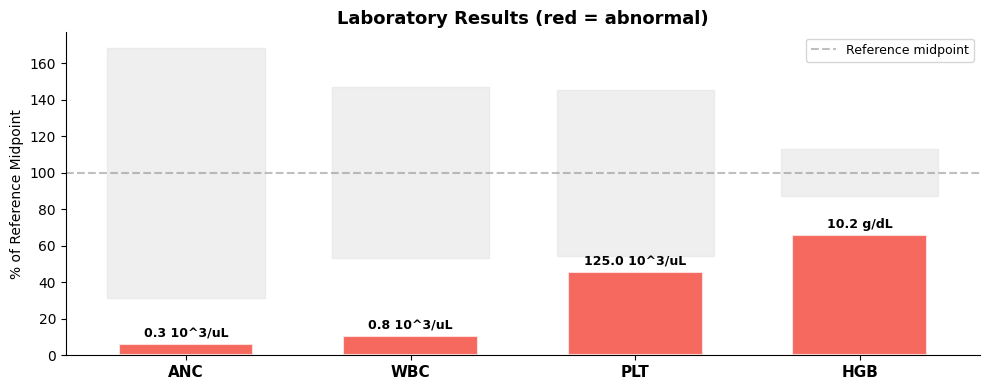

In [7]:
def plot_lab_results(patient):
    """Bar chart of lab results vs reference ranges."""
    records = patient["lb"]["records"]
    if not records:
        print("No lab data.")
        return
    
    names = [r["LBTESTCD"] for r in records]
    values = [float(r["LBORRES"]) for r in records]
    lo = [float(r["LBORNRLO"]) if r.get("LBORNRLO") else 0 for r in records]
    hi = [float(r["LBORNRHI"]) if r.get("LBORNRHI") else 0 for r in records]
    
    # Normalize to % of reference range midpoint for visualization
    mid = [(l + h) / 2 for l, h in zip(lo, hi)]
    pct_values = [v / m * 100 if m > 0 else 100 for v, m in zip(values, mid)]
    pct_lo = [l / m * 100 if m > 0 else 0 for l, m in zip(lo, mid)]
    pct_hi = [h / m * 100 if m > 0 else 200 for h, m in zip(hi, mid)]
    
    fig, ax = plt.subplots(figsize=(10, 4))
    bar_colors = ["#F44336" if v < l or v > h else "#4CAF50" for v, l, h in zip(values, lo, hi)]
    
    x = range(len(names))
    bars = ax.bar(x, pct_values, color=bar_colors, alpha=0.8, width=0.6, edgecolor="white", linewidth=1.5)
    
    # Reference range band
    for i in x:
        ax.fill_between([i - 0.35, i + 0.35], pct_lo[i], pct_hi[i],
                       color="#E0E0E0", alpha=0.5, zorder=0)
    
    # Value labels
    for i, (bar, v, u) in enumerate(zip(bars, values, [r["LBORRESU"] for r in records])):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{v} {u}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    
    ax.set_xticks(x)
    ax.set_xticklabels(names, fontsize=11, fontweight="bold")
    ax.set_ylabel("% of Reference Midpoint", fontsize=10)
    ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5, label="Reference midpoint")
    ax.set_title("Laboratory Results (red = abnormal)", fontsize=13, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

plot_lab_results(SAMPLE_PATIENT)

---
## 4. Prompt Formatting

The Doc Agent formats three distinct prompts from CRF data:
- **B5**: Full clinical narrative (pharmacovigilance writing)
- **C7**: Dechallenge assessment (did AE improve when drug stopped?)
- **C8**: Rechallenge assessment (did AE recur when drug restarted?)

In [8]:
# ============================================================
# Prompt formatting helpers (extracted from Doc Agent)
# ============================================================

def fmt_date(d):
    """Format date string as DD-MMM-YYYY."""
    if not d:
        return "N/A"
    if isinstance(d, str):
        d = datetime.strptime(d, "%Y-%m-%d")
    return d.strftime("%d-%b-%Y").upper()


def format_b5_prompt(patient, drug_name="Enfortumab vedotin (Padcev)",
                     indication="Metastatic urothelial carcinoma"):
    """Format the B5 clinical narrative prompt."""
    dm = patient["dm"]
    ae = patient["ae"]
    
    # Demographics
    dm_text = f"Subject ID: {dm['SUBJID']}\nAge: {dm['AGE']} years\nSex: {dm['SEX']}"
    
    # Exposure
    ec_lines = [f"Suspect drug: {drug_name}", f"Indication: {indication}"]
    for i, ec in enumerate(patient["ec"], 1):
        prefix = f"Exposure period {i}: " if len(patient["ec"]) > 1 else ""
        ec_lines.append(
            f"{prefix}{ec['ECDSTXT']} {ec['ECDOSFRQ']} {ec['ECROUTE']}\n"
            f"  Start: {fmt_date(ec['ECSTDAT'])}\n"
            f"  End: {fmt_date(ec['ECENDAT'])}"
        )
        if ec.get("ECDOSADJ"):
            ec_lines.append(f"  Dose adjustment: {ec['ECDOSADJ']}")
    ec_text = "\n".join(ec_lines)
    
    # AE
    sae_flags = []
    for flag, label in [("AESDTH", "Death"), ("AESLIFE", "Life-threatening"),
                        ("AESHOSP", "Hospitalization"), ("AESDISAB", "Disability"),
                        ("AESCONG", "Congenital anomaly"), ("AESMIE", "Other medically important")]:
        if ae.get(flag) == "Y":
            sae_flags.append(label)
    ae_text = (
        f"Term: {ae['AETERM']}\nOnset: {fmt_date(ae['AESTDAT'])}\n"
        f"End: {fmt_date(ae.get('AEENDAT'))}\nSeverity: {ae['AESEV']}\n"
        f"CTCAE Grade: {ae.get('AETOXGR', 'N/A')}\nSerious: {ae['AESER']}\n"
        f"Causality: {ae['AEREL']}\nAction taken: {ae['AEACN']}\n"
        f"Outcome: {ae['AEOUT']}\nSAE criteria: {', '.join(sae_flags) or 'None'}"
    )
    if ae.get("AESHOSP") == "Y":
        ae_text += f"\nHospitalization: {fmt_date(ae.get('AEHOSPSTDAT'))} to {fmt_date(ae.get('AEHOSPENDAT'))}"
    
    # Labs (filter to relevant)
    lab_lines = []
    for r in patient["lb"]["records"]:
        ref = f" (ref: {r['LBORNRLO']}-{r['LBORNRHI']})" if r.get("LBORNRLO") else ""
        lab_lines.append(f"{r['LBTEST']}: {r['LBORRES']} {r['LBORRESU']}{ref} [{fmt_date(r['LBDAT'])}]")
    lb_text = "\n".join(lab_lines) if lab_lines else "No relevant lab data"
    
    # Medical history
    mh_lines = [f"- {r['MHTERM']}{' (ongoing)' if r.get('MHONGO') == 'Y' else ''}"
                for r in patient.get("mh", {}).get("records", [])]
    mh_text = "\n".join(mh_lines) if mh_lines else "No relevant medical history"
    
    # Vitals
    vs_parts = []
    vs = patient.get("vs", {})
    if vs.get("WEIGHT"): vs_parts.append(f"Weight: {vs['WEIGHT']} kg")
    if vs.get("HEIGHT"): vs_parts.append(f"Height: {vs['HEIGHT']} cm")
    for r in vs.get("records", []):
        vs_parts.append(f"{r['VSTESTCD']}: {r['VSORRES']} {r['VSORRESU']}")
    vs_text = "\n".join(vs_parts) if vs_parts else "No vital signs data"
    
    # CM (baseline only in prompt; AE treatment also included for narrative context)
    cm_lines = []
    for r in patient.get("cm", {}).get("records", []):
        cat = r.get("CMCAT", "")
        prefix = "AE treatment: " if cat == "AE_TREATMENT" else ""
        cm_lines.append(f"- {prefix}{r['CMTRT']} {r.get('CMDSTXT', '')} (for {r.get('CMINDC', '')})")
    cm_text = "\n".join(cm_lines) if cm_lines else "No concomitant medications"
    
    # Imaging
    img_lines = []
    for r in patient.get("imaging", {}).get("records", []):
        img_lines.append(
            f"{r['IMG_MODALITY']} {r['IMG_REGION']} [{fmt_date(r['IMG_DAT'])}]:\n"
            f"  Findings: {r['IMG_FINDINGS']}\n"
            f"  Impression: {r['IMG_IMPRESSION']}"
        )
    img_text = "\n".join(img_lines) if img_lines else "No imaging studies available"
    
    # Microbiology
    mb_lines = []
    for r in patient.get("microbiology", {}).get("records", []):
        mb_lines.append(f"{r['MB_SPECIMEN']} {r['MB_TEST']} [{fmt_date(r['MB_DAT'])}]: {r['MB_RESULT']}")
    mb_text = "\n".join(mb_lines) if mb_lines else "No microbiology data available"
    
    # Consultation
    consult_lines = []
    for r in patient.get("consultation", {}).get("records", []):
        consult_lines.append(f"{r['CONSULT_SPECIALTY']} [{fmt_date(r['CONSULT_DAT'])}]:\n  {r['CONSULT_IMPRESSION']}")
    consult_text = "\n".join(consult_lines) if consult_lines else "No specialist consultation data available"
    
    # Assemble full prompt
    prompt = B5_TEMPLATE.format(
        report_type="Initial",
        dm_data=dm_text, ec_data=ec_text, ae_data=ae_text,
        lb_data=lb_text, mh_data=mh_text, vs_data=vs_text,
        cm_data=cm_text, dd_data="N/A (patient alive)",
        sentinel_output="No ILD-related clinical findings",
        imaging_data=img_text, pft_data="No pulmonary function test data available",
        microbiology_data=mb_text, consultation_data=consult_text,
    )
    return prompt


def format_c7_prompt(patient):
    """Format the C7 Dechallenge prompt."""
    ae = patient["ae"]
    ec_mod_date = "N/A"
    if ae["AEACN"] in ("DRUG WITHDRAWN", "DRUG INTERRUPTED"):
        for ec in patient["ec"]:
            if ec.get("ECENDAT"):
                ec_mod_date = fmt_date(ec["ECENDAT"])
                break
    
    return C7_TEMPLATE.format(
        aeacn=ae["AEACN"], aeout=ae["AEOUT"],
        aestdat=fmt_date(ae["AESTDAT"]),
        aeendat=fmt_date(ae.get("AEENDAT")),
        ecstdat=fmt_date(patient["ec"][0]["ECSTDAT"]) if patient["ec"] else "N/A",
        ec_modification_date=ec_mod_date,
    )


def format_c8_prompt(patient):
    """Format the C8 Rechallenge prompt."""
    ae = patient["ae"]
    ec_lines = []
    for i, ec in enumerate(patient["ec"], 1):
        ec_lines.append(
            f"Period {i}: {ec['ECDSTXT']} {ec['ECDOSFRQ']}, "
            f"Start: {fmt_date(ec['ECSTDAT'])}, End: {fmt_date(ec['ECENDAT'])}"
        )
    ec_history = "\n".join(ec_lines) if ec_lines else "Single exposure period only"
    
    ae_history = (
        f"- {ae['AETERM']}: onset {fmt_date(ae['AESTDAT'])}, "
        f"end {fmt_date(ae.get('AEENDAT'))}, outcome {ae['AEOUT']}"
    )
    
    return C8_TEMPLATE.format(
        ec_history=ec_history,
        ae_history=ae_history,
        current_aeterm=ae["AETERM"],
    )

In [9]:
# ============================================================
# Prompt templates (from Doc Agent prompts.py)
# ============================================================

B5_TEMPLATE = """You are a pharmacovigilance medical writer drafting an adverse event narrative for MedWatch FDA Form 3500A, Section B5.

Write a concise clinical narrative in chronological order based on the following patient data.

## Report Type
{report_type}
- If "Initial": Write the full narrative from onset
- If "Follow-up": Begin with "This is a follow-up to the initial report dated {{initial_report_date}}." then describe only new information.

## Patient Demographics (DM)
{dm_data}

## Study Drug Exposure (EC)
{ec_data}

## Adverse Event (AE)
{ae_data}

## Laboratory Results (LB)
{lb_data}

## Medical History (MH)
{mh_data}

## Vital Signs (VS)
{vs_data}

## Concomitant Medications (CM)
{cm_data}

## Death Details (DD)
{dd_data}

## ILD Clinical Findings
{sentinel_output}

## Imaging Studies
{imaging_data}

## Pulmonary Function Tests (PFT)
{pft_data}

## Microbiology Results
{microbiology_data}

## Specialist Consultations
{consultation_data}

## Rules

1. STRUCTURE: Opening "The subject (Subject [SUBJID]) is a [age]-year-old [sex] with a medical history of [conditions]..." then chronological: demographics, drug regimen, AE onset, workup, treatment, outcome.
2. FORMAT: Plain prose, past tense, DD-MMM-YYYY dates, lab values with units+ranges, 250-500 words. Use "the subject" (not "patient").
3. DRUG NAME: Use EXACT drug name from Suspect drug field. Do NOT invent names.
4. DO NOT: Make causality judgments, add missing info, use markdown, reference AI systems, include race/ethnicity, say "not specified", expose CRF codes."""


C7_TEMPLATE = """You are a pharmacovigilance specialist assessing dechallenge for MedWatch FDA Form 3500A, Section C7.

Based on the following data, determine whether the adverse event abated after the suspect drug was stopped or dose reduced.

## Drug Action Taken (AEACN)
{aeacn}

## AE Outcome (AEOUT)
{aeout}

## AE Start Date
{aestdat}

## AE End Date
{aeendat}

## Drug Stop/Modification Date
{ec_modification_date}

## Timeline Summary
Drug start: {ecstdat}
Drug action date: {ec_modification_date}
AE onset: {aestdat}
AE end: {aeendat}
AE outcome: {aeout}

## Rules
1. If AEACN = "DOSE NOT CHANGED" or "NOT APPLICABLE": -> "Does not apply"
2. If AEACN in ("DRUG WITHDRAWN", "DRUG INTERRUPTED", "DOSE REDUCED"):
   a. AEOUT resolved/recovering -> "Yes"
   b. AEOUT not resolved -> "No"
   c. AEOUT fatal -> "No"
3. If AEACN = "UNKNOWN" -> "Unknown"

## Output Format
Return ONLY a JSON object:
{{"c7_answer": "Yes" | "No" | "Does not apply" | "Unknown", "c7_rationale": "<one sentence with dates>"}}

Use clinical language only. Do NOT expose CRF codes. Use "the subject" not "patient"."""


C8_TEMPLATE = """You are a pharmacovigilance specialist assessing rechallenge for MedWatch FDA Form 3500A, Section C8.

## Exposure History (EC)
{ec_history}

## All Adverse Events (AE)
{ae_history}

## Current AE Term
{current_aeterm}

## Rules
1. Check EC for reintroduction pattern (start -> stop -> restart)
2. No reintroduction -> "Does not apply", e2b_code=4
3. Reintroduction found + AE recurred -> "Yes, recurred", e2b_code=1
4. Reintroduction found + AE did not recur -> "Yes, did not recur", e2b_code=2

## Output Format
Return ONLY a JSON object:
{{"c8_answer": "Yes, recurred" | "Yes, did not recur" | "Does not apply", "c8_rationale": "<one sentence>", "e2b_code": 1 | 2 | 4}}

Use clinical language only. Do NOT expose CRF codes. Use "the subject" not "patient"."""

print("Prompt templates loaded.")

Prompt templates loaded.


In [10]:
# Format prompts for our sample patient
b5_prompt = format_b5_prompt(SAMPLE_PATIENT)
c7_prompt = format_c7_prompt(SAMPLE_PATIENT)
c8_prompt = format_c8_prompt(SAMPLE_PATIENT)

print(f"B5 prompt: {len(b5_prompt)} chars")
print(f"C7 prompt: {len(c7_prompt)} chars")
print(f"C8 prompt: {len(c8_prompt)} chars")
print()
print("=" * 60)
print("B5 PROMPT (first 500 chars):")
print("=" * 60)
print(b5_prompt[:500])
print("...")

B5 prompt: 3112 chars
C7 prompt: 1093 chars
C8 prompt: 936 chars

B5 PROMPT (first 500 chars):
You are a pharmacovigilance medical writer drafting an adverse event narrative for MedWatch FDA Form 3500A, Section B5.

Write a concise clinical narrative in chronological order based on the following patient data.

## Report Type
Initial
- If "Initial": Write the full narrative from onset
- If "Follow-up": Begin with "This is a follow-up to the initial report dated {initial_report_date}." then describe only new information.

## Patient Demographics (DM)
Subject ID: PT-AE-001
Age: 52 years
Sex:
...


---
## 5. Model Inference

### 5.1 Inference Helper

In [11]:
def generate(prompt, max_new_tokens=1024, temperature=0.3, do_sample=True):
    """Run inference and return (text, metadata).
    
    Uses manual Gemma3 chat format since fine-tuned models
    may not have a chat_template in their tokenizer config.
    """
    # Gemma3 chat format (manual — FT model may lack chat_template)
    input_text = f"<bos><start_of_turn>user\n{prompt}<end_of_turn>\n<start_of_turn>model\n"
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]
    
    print(f"  Input tokens: {input_len}")
    
    t0 = time.time()
    with torch.no_grad():
        gen_kwargs = dict(
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
        )
        if do_sample:
            gen_kwargs.update(temperature=temperature, do_sample=True, top_p=0.95)
        else:
            gen_kwargs["do_sample"] = False
        outputs = model.generate(**inputs, **gen_kwargs)
    elapsed = time.time() - t0
    
    new_tokens = outputs[0][input_len:]
    output_len = len(new_tokens)
    text = tokenizer.decode(new_tokens, skip_special_tokens=True)
    
    meta = {
        "input_tokens": input_len,
        "output_tokens": output_len,
        "total_tokens": input_len + output_len,
        "elapsed_s": elapsed,
        "tokens_per_sec": output_len / elapsed if elapsed > 0 else 0,
    }
    
    print(f"  Output tokens: {output_len}")
    print(f"  Time: {elapsed:.2f}s ({meta['tokens_per_sec']:.1f} tok/s)")
    
    return text, meta

### 5.2 B5 — Clinical Narrative Generation

In [12]:
print("Generating B5 Narrative...")
b5_raw, b5_meta = generate(
    b5_prompt,
    max_new_tokens=MAX_NEW_TOKENS_NARRATIVE,
    temperature=TEMPERATURE_NARRATIVE,
)

print("\n" + "=" * 60)
print("RAW B5 OUTPUT:")
print("=" * 60)
print(b5_raw)

Generating B5 Narrative...
  Input tokens: 1047


  Output tokens: 540
  Time: 33.24s (16.2 tok/s)

RAW B5 OUTPUT:
## Narrative

The subject is a 52-year-old male with a medical history of HER2-positive metastatic breast cancer and prior chemotherapy with docetaxel.

On September 22, 2025, the subject began intravenous enfortumab vedotin (Padcev) for metastatic urothelial carcinoma at a dose of 5.4 mg/kg every 3 weeks.

On October 18, 2025, the subject developed fever and a low white blood cell count. The subject was hospitalized. Laboratory results on October 18, 2025, showed an absolute neutrophil count of 0.3 x 10^3/uL, a white blood cell count of 0.8 x 10^3/uL, and a platelet count of 125 x 10^3/uL. A chest X-ray on October 18, 2025, showed clear lung fields. Blood cultures obtained on October 15, 2025, showed no growth. An infectious disease consultation was held on October 16, 2025, which recommended empiric broad-spectrum antibiotics and growth factor support.

The subject was treated with filgrastim 5 mcg/kg subcutaneously dai

In [13]:
# ============================================================
# Post-process B5 narrative (clean model artifacts)
# ============================================================

def clean_narrative(text):
    """Clean MedGemma narrative output artifacts."""
    # Strip markdown headers
    text = re.sub(r"^#{1,6}\s+.*\n?", "", text, flags=re.MULTILINE)
    # Strip bold/italic markers
    text = re.sub(r"\*{1,3}([^*]+)\*{1,3}", r"\1", text)
    # Strip bullet points
    text = re.sub(r"^[-*]\s+", "", text, flags=re.MULTILINE)
    # Remove CRF data echo (model sometimes repeats input data)
    crf_patterns = [
        r"^Term:\s", r"^Onset:\s", r"^Severity:\s", r"^CTCAE Grade:\s",
        r"^Serious:\s", r"^Causality:\s", r"^Action taken:\s",
        r"^Outcome:\s", r"^SAE criteria:\s",
    ]
    lines = text.split("\n")
    cut = len(lines)
    for i, line in enumerate(lines):
        for pat in crf_patterns:
            if re.match(pat, line.strip(), re.IGNORECASE):
                cut = i
                break
        if cut < len(lines):
            break
    text = "\n".join(lines[:cut]).strip()
    
    # Deduplicate paragraphs
    paras = re.split(r"\n\n+", text)
    seen = set()
    unique = []
    for p in paras:
        norm = p.strip()
        if norm and norm not in seen:
            seen.add(norm)
            unique.append(p)
    text = "\n\n".join(unique)
    
    # Normalize whitespace
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    return text


b5_clean = clean_narrative(b5_raw)

print("=" * 60)
print("CLEANED B5 NARRATIVE:")
print("=" * 60)
print(b5_clean)
print()
print(f"Word count: {len(b5_clean.split())}")
print(f"Sentence count: {len([s for s in b5_clean.split('.') if s.strip()])}")

CLEANED B5 NARRATIVE:
The subject is a 52-year-old male with a medical history of HER2-positive metastatic breast cancer and prior chemotherapy with docetaxel.

On September 22, 2025, the subject began intravenous enfortumab vedotin (Padcev) for metastatic urothelial carcinoma at a dose of 5.4 mg/kg every 3 weeks.

On October 18, 2025, the subject developed fever and a low white blood cell count. The subject was hospitalized. Laboratory results on October 18, 2025, showed an absolute neutrophil count of 0.3 x 10^3/uL, a white blood cell count of 0.8 x 10^3/uL, and a platelet count of 125 x 10^3/uL. A chest X-ray on October 18, 2025, showed clear lung fields. Blood cultures obtained on October 15, 2025, showed no growth. An infectious disease consultation was held on October 16, 2025, which recommended empiric broad-spectrum antibiotics and growth factor support.

The subject was treated with filgrastim 5 mcg/kg subcutaneously daily and piperacillin-tazobactam 4.5 g intravenously every 

In [14]:
# Render the narrative nicely
display(HTML(f"""
<div style="background: #f8f9fa; border-left: 4px solid #1976D2; padding: 16px; 
            border-radius: 4px; font-family: Georgia, serif; line-height: 1.7;">
    <h4 style="margin-top: 0; color: #1976D2;">Section B5 — Clinical Narrative</h4>
    <p style="color: #333;">{b5_clean.replace(chr(10), '<br>')}</p>
</div>
"""))

### 5.3 C7 — Dechallenge Assessment

In [15]:
print("Generating C7 Dechallenge...")
c7_raw, c7_meta = generate(
    c7_prompt,
    max_new_tokens=MAX_NEW_TOKENS_STRUCTURED,
    temperature=TEMPERATURE_STRUCTURED,
    do_sample=False,  # Greedy for structured output
)

print("\nRaw output:")
print(c7_raw)

Generating C7 Dechallenge...
  Input tokens: 392


  Output tokens: 65
  Time: 3.88s (16.8 tok/s)

Raw output:
```json
{"c7_answer": "Yes", "c7_rationale": "The adverse event (AE) started on 18-OCT-2025, the same date the drug was interrupted, and resolved by 02-NOV-2025."}
```


In [16]:
def parse_c7c8(raw):
    """Parse structured JSON from C7/C8 model output."""
    text = raw.strip()
    # Strip thinking tokens
    text = re.sub(r"<unused\d+>.*?</unused\d+>", "", text, flags=re.DOTALL).strip()
    # Try to find JSON object
    json_match = re.search(r"\{[^{}]*(?:\"c[78]_answer\"|\"c[78]_rationale\")[^{}]*\}", text, flags=re.DOTALL)
    if json_match:
        try:
            return json.loads(json_match.group())
        except json.JSONDecodeError:
            pass
    # Try stripping markdown fences
    if "```" in text:
        fenced = re.search(r"```(?:json)?\s*\n?(.*?)\n?\s*```", text, flags=re.DOTALL)
        if fenced:
            text = fenced.group(1).strip()
    try:
        return json.loads(text)
    except (json.JSONDecodeError, TypeError):
        return {"raw": raw}


c7_parsed = parse_c7c8(c7_raw)
print("Parsed C7 result:")
print(json.dumps(c7_parsed, indent=2))

c7_answer = c7_parsed.get("c7_answer", "Unknown")
c7_rationale = c7_parsed.get("c7_rationale", c7_raw)

answer_color = {"Yes": "#4CAF50", "No": "#F44336", "Does not apply": "#FF9800", "Unknown": "#9E9E9E"}
display(HTML(f"""
<div style="background: #f8f9fa; border-left: 4px solid {answer_color.get(c7_answer, '#9E9E9E')}; 
            padding: 16px; border-radius: 4px;">
    <h4 style="margin-top: 0;">Section C7 — Dechallenge</h4>
    <p><strong>Answer:</strong> <span style="color: {answer_color.get(c7_answer, '#333')}; font-size: 18px;">{c7_answer}</span></p>
    <p><strong>Rationale:</strong> {c7_rationale}</p>
</div>
"""))

Parsed C7 result:
{
  "c7_answer": "Yes",
  "c7_rationale": "The adverse event (AE) started on 18-OCT-2025, the same date the drug was interrupted, and resolved by 02-NOV-2025."
}


### 5.4 C8 — Rechallenge Assessment

In [17]:
# Check if rechallenge is applicable (need 2+ exposure periods with stop->restart)
has_rechallenge = False
ec_list = SAMPLE_PATIENT["ec"]
if len(ec_list) >= 2:
    for ec in ec_list:
        if ec.get("ECENDAT"):
            for other in ec_list:
                if other is not ec and other.get("ECSTDAT"):
                    if other["ECSTDAT"] > ec["ECENDAT"]:
                        has_rechallenge = True
                        break
        if has_rechallenge:
            break

if has_rechallenge:
    print("Rechallenge pattern detected. Generating C8...")
    c8_raw, c8_meta = generate(
        c8_prompt,
        max_new_tokens=MAX_NEW_TOKENS_STRUCTURED,
        temperature=TEMPERATURE_STRUCTURED,
        do_sample=False,
    )
    print("\nRaw output:")
    print(c8_raw)
else:
    print("No rechallenge pattern (single exposure or no restart). Skipping C8 inference.")
    c8_raw = '{"c8_answer": "Does not apply", "c8_rationale": "Single exposure period only", "e2b_code": 4}'
    c8_meta = {"input_tokens": 0, "output_tokens": 0, "total_tokens": 0, "elapsed_s": 0, "tokens_per_sec": 0}

Rechallenge pattern detected. Generating C8...
  Input tokens: 351


  Output tokens: 59
  Time: 3.00s (19.7 tok/s)

Raw output:
```json
{"c8_answer": "Yes, recurred", "c8_rationale": "The subject was previously exposed to the medication and experienced febrile neutropenia, which recurred upon reintroduction.", "e2b_code": 1}
```


In [18]:
c8_parsed = parse_c7c8(c8_raw)
print("Parsed C8 result:")
print(json.dumps(c8_parsed, indent=2))

c8_answer = c8_parsed.get("c8_answer", "Does not apply")
c8_rationale = c8_parsed.get("c8_rationale", c8_raw)
c8_e2b = c8_parsed.get("e2b_code", 4)

e2b_map = {1: "Reaction recurred", 2: "Reaction did not recur", 4: "Not applicable"}

display(HTML(f"""
<div style="background: #f8f9fa; border-left: 4px solid #9C27B0; padding: 16px; border-radius: 4px;">
    <h4 style="margin-top: 0;">Section C8 — Rechallenge</h4>
    <p><strong>Answer:</strong> <span style="font-size: 18px;">{c8_answer}</span></p>
    <p><strong>Rationale:</strong> {c8_rationale}</p>
    <p><strong>E2B Code:</strong> {c8_e2b} ({e2b_map.get(c8_e2b, 'Unknown')})</p>
</div>
"""))

Parsed C8 result:
{
  "c8_answer": "Yes, recurred",
  "c8_rationale": "The subject was previously exposed to the medication and experienced febrile neutropenia, which recurred upon reintroduction.",
  "e2b_code": 1
}


---
## 6. Inference Statistics & Visualization

In [19]:
# Aggregate all inference stats
all_meta = {
    "B5 Narrative": b5_meta,
    "C7 Dechallenge": c7_meta,
    "C8 Rechallenge": c8_meta,
}

stats_df = pd.DataFrame(all_meta).T
stats_df["tokens_per_sec"] = stats_df["tokens_per_sec"].round(1)
stats_df["elapsed_s"] = stats_df["elapsed_s"].round(2)

display(HTML("<h3>Inference Statistics</h3>"))
display(stats_df.style.format({
    "elapsed_s": "{:.2f}s",
    "tokens_per_sec": "{:.1f}",
}).set_properties(**{"text-align": "center"}))

,input_tokens,output_tokens,total_tokens,elapsed_s,tokens_per_sec
B5 Narrative,1047.000000,540.000000,1587.000000,33.24s,16.2
C7 Dechallenge,392.000000,65.000000,457.000000,3.88s,16.8
C8 Rechallenge,351.000000,59.000000,410.000000,3.00s,19.7


/tmp/ipykernel_1709532/2887821202.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["B5", "C7", "C8"], fontsize=11)
/tmp/ipykernel_1709532/2887821202.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["B5", "C7", "C8"], fontsize=11)


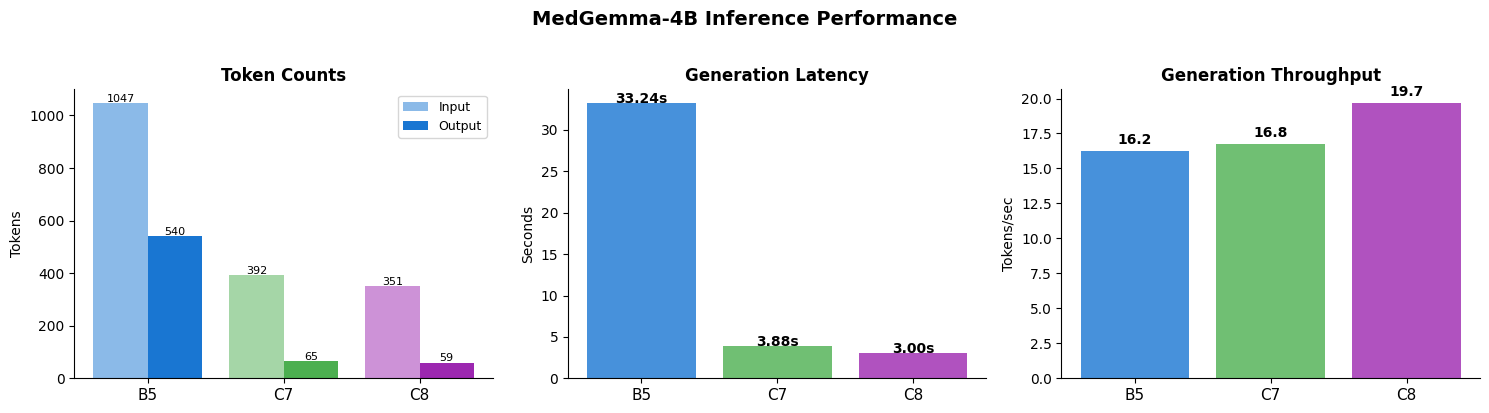


Total: 2454 tokens in 40.12s


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = list(all_meta.keys())
colors = ["#1976D2", "#4CAF50", "#9C27B0"]

# Token counts
ax = axes[0]
input_tok = [all_meta[k]["input_tokens"] for k in labels]
output_tok = [all_meta[k]["output_tokens"] for k in labels]
x = range(len(labels))
bars1 = ax.bar(x, input_tok, width=0.4, label="Input", color=[c + "80" for c in colors], align="center")
bars2 = ax.bar([i + 0.4 for i in x], output_tok, width=0.4, label="Output", color=colors, align="center")
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(["B5", "C7", "C8"], fontsize=11)
ax.set_ylabel("Tokens")
ax.set_title("Token Counts", fontweight="bold")
ax.legend(fontsize=9)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", fontsize=8)

# Latency
ax = axes[1]
times = [all_meta[k]["elapsed_s"] for k in labels]
bars = ax.bar(labels, times, color=colors, alpha=0.8)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{t:.2f}s", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Seconds")
ax.set_title("Generation Latency", fontweight="bold")
ax.set_xticklabels(["B5", "C7", "C8"], fontsize=11)

# Throughput
ax = axes[2]
tps = [all_meta[k]["tokens_per_sec"] for k in labels]
bars = ax.bar(labels, tps, color=colors, alpha=0.8)
for bar, t in zip(bars, tps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{t:.1f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Tokens/sec")
ax.set_title("Generation Throughput", fontweight="bold")
ax.set_xticklabels(["B5", "C7", "C8"], fontsize=11)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(f"MedGemma-4B Inference Performance", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

total_time = sum(times)
total_tokens = sum(all_meta[k]["total_tokens"] for k in labels)
print(f"\nTotal: {total_tokens} tokens in {total_time:.2f}s")

---
## 7. MedWatch 3500A Summary

Final assembled report sections:

In [21]:
dm = SAMPLE_PATIENT["dm"]
ae = SAMPLE_PATIENT["ae"]

# Dechallenge display
c7_display = f"{c7_parsed.get('c7_answer', 'Unknown')} — {c7_parsed.get('c7_rationale', '')}"
# Rechallenge display
c8_display = f"{c8_parsed.get('c8_answer', 'N/A')} — {c8_parsed.get('c8_rationale', '')}"

display(HTML(f"""
<div style="max-width: 800px; font-family: -apple-system, sans-serif;">
  <h2 style="text-align: center; color: #1565C0; border-bottom: 2px solid #1565C0; padding-bottom: 8px;">
    MedWatch FDA Form 3500A — Summary
  </h2>
  
  <table style="width: 100%; border-collapse: collapse; margin-bottom: 20px;">
    <tr style="background: #E3F2FD;">
      <td colspan="2" style="padding: 8px; font-weight: bold; font-size: 14px; color: #1565C0;">
        Section A — Patient Information
      </td>
    </tr>
    <tr><td style="padding: 6px; width: 35%; font-weight: bold;">Patient ID</td>
        <td style="padding: 6px;">{dm['SUBJID']}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Age / Sex</td>
        <td style="padding: 6px;">{dm['AGE']} years / {dm['SEX']}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Weight</td>
        <td style="padding: 6px;">{SAMPLE_PATIENT['vs'].get('WEIGHT', 'N/A')} kg</td></tr>
  </table>
  
  <table style="width: 100%; border-collapse: collapse; margin-bottom: 20px;">
    <tr style="background: #FFEBEE;">
      <td colspan="2" style="padding: 8px; font-weight: bold; font-size: 14px; color: #C62828;">
        Section B — Adverse Event
      </td>
    </tr>
    <tr><td style="padding: 6px; width: 35%; font-weight: bold;">Event</td>
        <td style="padding: 6px;">{ae['AETERM']} (CTCAE Grade {ae.get('AETOXGR', 'N/A')})</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Onset</td>
        <td style="padding: 6px;">{fmt_date(ae['AESTDAT'])}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Outcome</td>
        <td style="padding: 6px;">{ae['AEOUT']}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Seriousness</td>
        <td style="padding: 6px;">Hospitalization, Other medically important</td></tr>
    <tr><td colspan="2" style="padding: 6px; font-weight: bold;">B5 — Narrative</td></tr>
    <tr><td colspan="2" style="padding: 10px; background: #FFF3E0; font-style: italic; line-height: 1.6;">
        {b5_clean[:600]}{'...' if len(b5_clean) > 600 else ''}
    </td></tr>
  </table>
  
  <table style="width: 100%; border-collapse: collapse; margin-bottom: 20px;">
    <tr style="background: #E8F5E9;">
      <td colspan="2" style="padding: 8px; font-weight: bold; font-size: 14px; color: #2E7D32;">
        Section C — Suspect Product
      </td>
    </tr>
    <tr><td style="padding: 6px; width: 35%; font-weight: bold;">Drug</td>
        <td style="padding: 6px;">Enfortumab vedotin (Padcev)</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">Dose</td>
        <td style="padding: 6px;">{SAMPLE_PATIENT['ec'][0]['ECDSTXT']} {SAMPLE_PATIENT['ec'][0]['ECDOSFRQ']} {SAMPLE_PATIENT['ec'][0]['ECROUTE']}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">C7 — Dechallenge</td>
        <td style="padding: 6px;">{c7_display}</td></tr>
    <tr><td style="padding: 6px; font-weight: bold;">C8 — Rechallenge</td>
        <td style="padding: 6px;">{c8_display}</td></tr>
  </table>
</div>
"""))

---
## 8. Batch Processing — Multiple Patients

Run inference on additional patient cases to evaluate model quality across diverse AE types.

In [22]:
# Additional sample patients for batch testing
BATCH_PATIENTS = [
    {
        "name": "PT-AE-002 (Pneumonitis, Grade 3, Fatal)",
        "data": {
            "dm": {"SUBJID": "PT-AE-002", "AGE": 68, "SEX": "Female", "RACE": "White", "ETHNIC": ""},
            "ae": {
                "AETERM": "Pneumonitis", "AESTDAT": "2025-11-05", "AEENDAT": "2025-12-01",
                "AESEV": "SEVERE", "AESER": "Y", "AETOXGR": "3", "AEREL": "Probable",
                "AEACN": "DRUG WITHDRAWN", "AEOUT": "FATAL",
                "AESDTH": "Y", "AESLIFE": "Y", "AESHOSP": "Y",
                "AESDISAB": "N", "AESCONG": "N", "AESMIE": "N",
                "AEHOSPSTDAT": "2025-11-08", "AEHOSPENDAT": "2025-12-01"
            },
            "ec": [{"ECDSTXT": "200 mg", "ECDOSFRQ": "Q3W", "ECROUTE": "Intravenous",
                    "ECSTDAT": "2025-09-01", "ECENDAT": "2025-11-05",
                    "ECDOSADJ": "Permanently discontinued due to pneumonitis"}],
            "lb": {"records": [
                {"LBTESTCD": "KL6", "LBTEST": "KL-6", "LBORRES": "1250", "LBORRESU": "U/mL",
                 "LBORNRLO": "0", "LBORNRHI": "500", "LBDAT": "2025-11-08"},
                {"LBTESTCD": "LDH", "LBTEST": "Lactate Dehydrogenase", "LBORRES": "480", "LBORRESU": "U/L",
                 "LBORNRLO": "140", "LBORNRHI": "280", "LBDAT": "2025-11-08"},
            ]},
            "cm": {"records": [{"CMTRT": "Methylprednisolone", "CMINDC": "Pneumonitis",
                                "CMDSTXT": "1 mg/kg IV", "CMSTDAT": "2025-11-08",
                                "CMENDAT": None, "CMCAT": "AE_TREATMENT"}]},
            "mh": {"records": [{"MHTERM": "Non-small cell lung cancer", "MHSTDAT": "2025-03-01",
                                "MHENDAT": None, "MHONGO": "Y"}]},
            "vs": {"records": [{"VSTESTCD": "SPO2", "VSORRES": "88", "VSORRESU": "%", "VSDAT": "2025-11-08"}],
                   "WEIGHT": 62.0, "HEIGHT": 165.0},
            "imaging": {"records": []}, "microbiology": {"records": []}, "consultation": {"records": []}
        }
    },
    {
        "name": "PT-AE-003 (Skin rash, Grade 2, Resolved)",
        "data": {
            "dm": {"SUBJID": "PT-AE-003", "AGE": 45, "SEX": "Male", "RACE": "Asian", "ETHNIC": ""},
            "ae": {
                "AETERM": "Maculopapular rash", "AESTDAT": "2025-10-10", "AEENDAT": "2025-10-25",
                "AESEV": "MODERATE", "AESER": "Y", "AETOXGR": "2", "AEREL": "Related",
                "AEACN": "DOSE NOT CHANGED", "AEOUT": "RECOVERED/RESOLVED",
                "AESDTH": "N", "AESLIFE": "N", "AESHOSP": "N",
                "AESDISAB": "N", "AESCONG": "N", "AESMIE": "Y",
                "AEHOSPSTDAT": None, "AEHOSPENDAT": None
            },
            "ec": [{"ECDSTXT": "5.4 mg/kg", "ECDOSFRQ": "Q3W", "ECROUTE": "Intravenous",
                    "ECSTDAT": "2025-09-15", "ECENDAT": None, "ECDOSADJ": None}],
            "lb": {"records": [
                {"LBTESTCD": "ANC", "LBTEST": "Absolute Neutrophil Count", "LBORRES": "4.2",
                 "LBORRESU": "10^3/uL", "LBORNRLO": "1.5", "LBORNRHI": "8.0", "LBDAT": "2025-10-12"}
            ]},
            "cm": {"records": [{"CMTRT": "Hydrocortisone cream", "CMINDC": "Rash",
                                "CMDSTXT": "1% topical BID", "CMSTDAT": "2025-10-10",
                                "CMENDAT": "2025-10-25", "CMCAT": "AE_TREATMENT"}]},
            "mh": {"records": [{"MHTERM": "Metastatic urothelial carcinoma", "MHSTDAT": "2025-04-01",
                                "MHENDAT": None, "MHONGO": "Y"}]},
            "vs": {"records": [], "WEIGHT": 75.0, "HEIGHT": 172.0},
            "imaging": {"records": []}, "microbiology": {"records": []}, "consultation": {"records": []}
        }
    },
]

print(f"Batch patients loaded: {len(BATCH_PATIENTS)}")
for p in BATCH_PATIENTS:
    print(f"  - {p['name']}")

Batch patients loaded: 2
  - PT-AE-002 (Pneumonitis, Grade 3, Fatal)
  - PT-AE-003 (Skin rash, Grade 2, Resolved)


In [23]:
# Run batch inference
batch_results = []

# Include the first patient
batch_results.append({
    "patient": SAMPLE_PATIENT["dm"]["SUBJID"],
    "ae_term": SAMPLE_PATIENT["ae"]["AETERM"],
    "grade": SAMPLE_PATIENT["ae"]["AETOXGR"],
    "b5_words": len(b5_clean.split()),
    "b5_time": b5_meta["elapsed_s"],
    "c7_answer": c7_parsed.get("c7_answer", "Unknown"),
    "c7_time": c7_meta["elapsed_s"],
    "c8_answer": c8_parsed.get("c8_answer", "N/A"),
    "c8_time": c8_meta["elapsed_s"],
    "total_time": b5_meta["elapsed_s"] + c7_meta["elapsed_s"] + c8_meta["elapsed_s"],
})

for p in BATCH_PATIENTS:
    print(f"\n{'=' * 60}")
    print(f"Processing: {p['name']}")
    print(f"{'=' * 60}")
    
    pt = p["data"]
    
    # B5
    print("\n[B5 Narrative]")
    prompt = format_b5_prompt(pt)
    raw, meta_b5 = generate(prompt, max_new_tokens=MAX_NEW_TOKENS_NARRATIVE, temperature=TEMPERATURE_NARRATIVE)
    narrative = clean_narrative(raw)
    print(f"  -> {len(narrative.split())} words")
    
    # C7
    print("\n[C7 Dechallenge]")
    prompt = format_c7_prompt(pt)
    raw, meta_c7 = generate(prompt, max_new_tokens=MAX_NEW_TOKENS_STRUCTURED, temperature=TEMPERATURE_STRUCTURED, do_sample=False)
    c7 = parse_c7c8(raw)
    print(f"  -> {c7.get('c7_answer', 'Parse error')}")
    
    # C8 (if applicable)
    c8 = {"c8_answer": "Does not apply", "c8_rationale": "Single exposure", "e2b_code": 4}
    meta_c8 = {"elapsed_s": 0}
    ec_list = pt["ec"]
    has_rechallenge = False
    if len(ec_list) >= 2:
        for ec in ec_list:
            if ec.get("ECENDAT"):
                for other in ec_list:
                    if other is not ec and other.get("ECSTDAT") and other["ECSTDAT"] > ec["ECENDAT"]:
                        has_rechallenge = True
                        break
            if has_rechallenge:
                break
    if has_rechallenge:
        print("\n[C8 Rechallenge]")
        prompt = format_c8_prompt(pt)
        raw, meta_c8 = generate(prompt, max_new_tokens=MAX_NEW_TOKENS_STRUCTURED, temperature=TEMPERATURE_STRUCTURED, do_sample=False)
        c8 = parse_c7c8(raw)
        print(f"  -> {c8.get('c8_answer', 'Parse error')}")
    else:
        print("\n[C8 Rechallenge] Skipped (no rechallenge pattern)")
    
    batch_results.append({
        "patient": pt["dm"]["SUBJID"],
        "ae_term": pt["ae"]["AETERM"],
        "grade": pt["ae"]["AETOXGR"],
        "b5_words": len(narrative.split()),
        "b5_time": meta_b5["elapsed_s"],
        "c7_answer": c7.get("c7_answer", "Unknown"),
        "c7_time": meta_c7["elapsed_s"],
        "c8_answer": c8.get("c8_answer", "N/A"),
        "c8_time": meta_c8["elapsed_s"],
        "total_time": meta_b5["elapsed_s"] + meta_c7["elapsed_s"] + meta_c8["elapsed_s"],
    })

print("\nBatch processing complete!")


Processing: PT-AE-002 (Pneumonitis, Grade 3, Fatal)

[B5 Narrative]
  Input tokens: 735


  Output tokens: 351
  Time: 19.68s (17.8 tok/s)
  -> 168 words

[C7 Dechallenge]
  Input tokens: 384


  Output tokens: 51
  Time: 2.49s (20.5 tok/s)
  -> Yes

[C8 Rechallenge] Skipped (no rechallenge pattern)

Processing: PT-AE-003 (Skin rash, Grade 2, Resolved)

[B5 Narrative]
  Input tokens: 650


  Output tokens: 356
  Time: 18.97s (18.8 tok/s)
  -> 201 words

[C7 Dechallenge]
  Input tokens: 379


  Output tokens: 77
  Time: 4.51s (17.1 tok/s)
  -> Yes

[C8 Rechallenge] Skipped (no rechallenge pattern)

Batch processing complete!


In [24]:
# Batch results summary
results_df = pd.DataFrame(batch_results)

display(HTML("<h3>Batch Results Summary</h3>"))
display(results_df.style.format({
    "b5_time": "{:.2f}s",
    "c7_time": "{:.2f}s",
    "c8_time": "{:.2f}s",
    "total_time": "{:.2f}s",
}).set_properties(**{"text-align": "center"}))

,patient,ae_term,grade,b5_words,b5_time,c7_answer,c7_time,c8_answer,c8_time,total_time
0,PT-AE-001,Febrile neutropenia,3,313,33.24s,Yes,3.88s,"Yes, recurred",3.00s,40.12s
1,PT-AE-002,Pneumonitis,3,168,19.68s,Yes,2.49s,Does not apply,0.00s,22.17s
2,PT-AE-003,Maculopapular rash,2,201,18.97s,Yes,4.51s,Does not apply,0.00s,23.48s


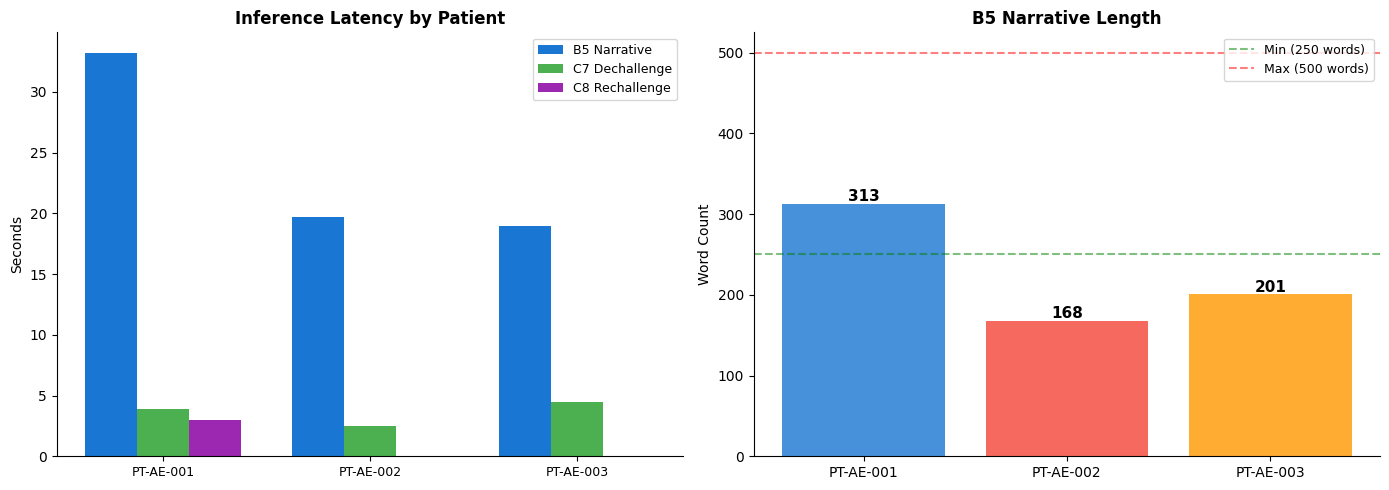

In [25]:
# Batch visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Latency breakdown per patient
ax = axes[0]
patients = results_df["patient"]
x = range(len(patients))
width = 0.25
ax.bar([i - width for i in x], results_df["b5_time"], width, label="B5 Narrative", color="#1976D2")
ax.bar(x, results_df["c7_time"], width, label="C7 Dechallenge", color="#4CAF50")
ax.bar([i + width for i in x], results_df["c8_time"], width, label="C8 Rechallenge", color="#9C27B0")
ax.set_xticks(x)
ax.set_xticklabels(patients, fontsize=9)
ax.set_ylabel("Seconds")
ax.set_title("Inference Latency by Patient", fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Narrative word counts
ax = axes[1]
bars = ax.bar(patients, results_df["b5_words"], color=["#1976D2", "#F44336", "#FF9800"], alpha=0.8)
ax.axhline(y=250, color="green", linestyle="--", alpha=0.5, label="Min (250 words)")
ax.axhline(y=500, color="red", linestyle="--", alpha=0.5, label="Max (500 words)")
for bar, w in zip(bars, results_df["b5_words"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(w), ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Word Count")
ax.set_title("B5 Narrative Length", fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Cleanup

In [26]:
# Free GPU memory
if torch.cuda.is_available():
    mem_before = torch.cuda.memory_allocated() / 1e9
    del model
    del tokenizer
    torch.cuda.empty_cache()
    mem_after = torch.cuda.memory_allocated() / 1e9
    print(f"GPU memory freed: {mem_before:.2f} GB -> {mem_after:.2f} GB")
else:
    del model
    del tokenizer
    print("Model and tokenizer released.")

GPU memory freed: 8.61 GB -> 0.01 GB
